# DDPM Example Usage

This script walks through the full workflow:
setup → train → save/load → generate → plot.
Make sure the `ddpm/` package folder is in the same directory (or on your PYTHONPATH).

In [5]:
!find . -maxdepth 3 -type d -name "ddpm"

In [4]:
import sys
sys.path.append(r"C:\Users\lodik\Documents\programming\diffusion-models-project-main")  # change this to the folder containing ddpm
import torch
from ddpm import NoiseScheduler, UNet, train, find_lr, generate_image, noisy_image
from ddpm.dataset import load_mnist, get_noisy_loaders
from ddpm.utils import load_unet, channel_list, model_name, path_name
from ddpm.viz import plot_generated

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ModuleNotFoundError: No module named 'ddpm'

In [ ]:
seed = 42
import random
import numpy as np

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 1. Noise scheduler and data

The scheduler defines the beta schedule and handles the forward noising process.
T=1000 steps, linearly spaced betas from 1e-4 to 0.02 (Ho et al. defaults).

In [ ]:
scheduler = NoiseScheduler(T=1000, beta_start=1e-4, beta_end=0.02)

train_set, test_set = load_mnist()
train_loader, test_loader = get_noisy_loaders(train_set, test_set, scheduler, batch_size=32)

### Training on a single digit

Pass a filter function to get_noisy_loaders_filtered to restrict the dataset.
Here we train on zeros only, but any (dataset -> Subset) function works.

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.1751 | test loss: 0.0923


train:   0%|          | 0/186 [00:00<?, ?it/s]

...

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 48 | train loss: 0.0326 | test loss: 0.0328


train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 49 | train loss: 0.0320 | test loss: 0.0337


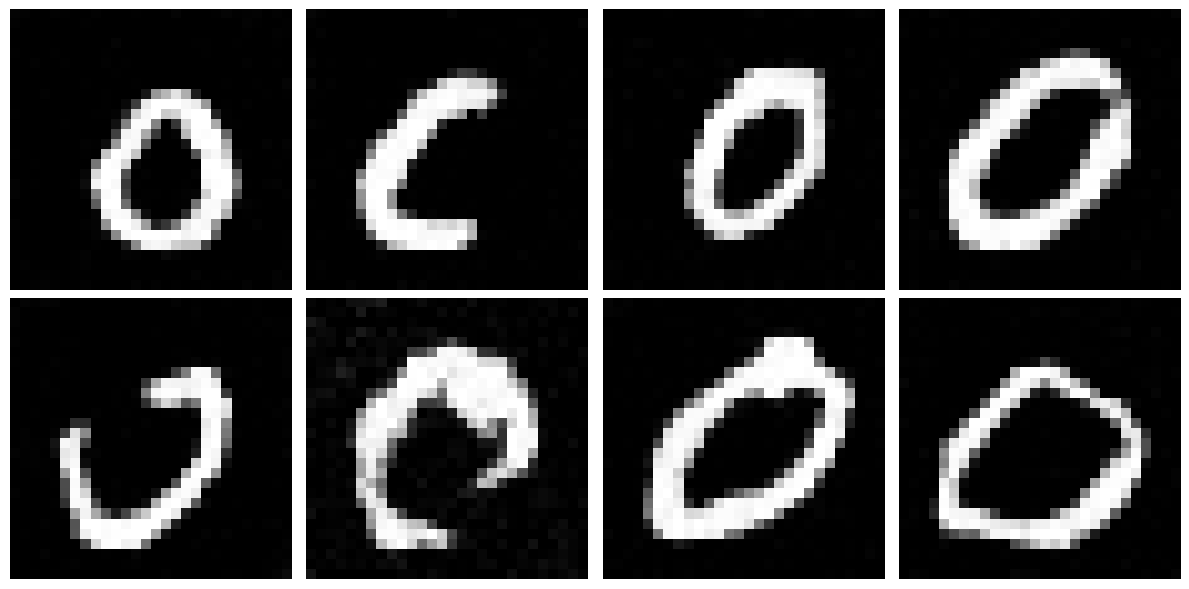

In [ ]:
# no self attention
from ddpm.dataset import get_noisy_loaders_filtered, zeros_only

train_loader_zeros, test_loader_zeros = get_noisy_loaders_filtered(
    train_set, test_set, scheduler, filter_fn=zeros_only, batch_size=32
)

unet_zeros = UNet(channels=channel_list(64), convs_per_level=2).to(device)
train_losses, test_losses = train(
    unet_zeros, train_loader_zeros, test_loader_zeros,
    epochs=50, lr=1e-3, save_path='zeros_only.pkl'
)

x = generate_image(unet_zeros, scheduler, n_images=8)
plot_generated(x, ncol=4)

In [ ]:
import torch
import model
import model_att

channels = [64, 128, 256]
cpl = 2

torch.manual_seed(123)
m_base = model.UNet(channels=channels, convs_per_level=cpl)

torch.manual_seed(123)
m_att0 = model_att.UNet(channels=channels, convs_per_level=cpl, num_heads_att=0)

x = torch.randn(8, 1, 28, 28)

with torch.no_grad():
    y_base = m_base(x)
    y_att0 = m_att0(x)

print("max diff:", (y_base - y_att0).abs().max().item())

max diff: 0.0


In [ ]:
# with self attention
from ddpm.dataset import get_noisy_loaders_filtered, zeros_only

train_loader_zeros, test_loader_zeros = get_noisy_loaders_filtered(
    train_set, test_set, scheduler, filter_fn=zeros_only, batch_size=32
)

unet_zeros = UNet(channels=channel_list(64), convs_per_level=2, num_heads_att=0).to(device)
train_losses, test_losses = train(
    unet_zeros, train_loader_zeros, test_loader_zeros,
    epochs=50, lr=1e-3, save_path='zeros_only.pkl'
)

x = generate_image(unet_zeros, scheduler, n_images=8)
plot_generated(x, ncol=4)

TypeError: UNet.__init__() got an unexpected keyword argument 'num_heads_att'

## 2. Build a UNet

`channels` sets the feature map depth at each encoder level.
The decoder mirrors this automatically.
`convs_per_level` is how many conv layers per resolution block. look at the documentation of UNet for a bit more detail (or ask Elias). The structure of the unet is basically taken from ronneberger et al., 2015 (the original unet paper, see also illustration in lilian wengs blog).

A reasonable small model to start with:

In [ ]:
channels = channel_list(64)   # -> [64, 128, 256]
cpl = 2                       # convs per level

unet = UNet(channels=channels, convs_per_level=cpl).to(device)
print(f"Model: {model_name(64, cpl)}")
print(f"Parameters: {sum(p.numel() for p in unet.parameters()):,}")

Model: C0_64_convs_2
Parameters: 2,145,665


## 3. Find a learning rate

Runs the LR range test and returns the suggested LR.
Multiply by ~0.5 for a conservative starting point.

  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 3.94E-03


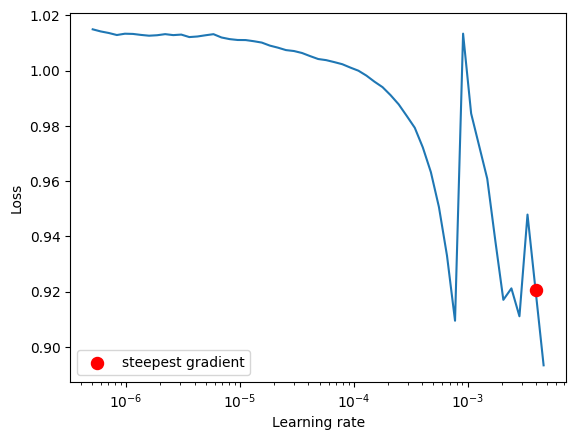

Suggested LR: 3.94e-03 → using 1.97e-03


In [ ]:
suggested_lr = find_lr(unet, train_loader)
lr = suggested_lr * 0.5
print(f"Suggested LR: {suggested_lr:.2e} → using {lr:.2e}")

## 4. Train

`train()` returns the loss histories and saves the best checkpoint automatically.
Early stopping kicks in after `early_stopping_patience` epochs without improvement.

In [ ]:
save_path = path_name(64, cpl)   # e.g. "base_C0_64_convs_2.pkl"

train_losses, test_losses = train(
    unet, train_loader, test_loader,
    epochs=50,
    lr=lr,
    weight_decay=1e-6,
    early_stopping_patience=10,
    save_path=save_path,
)

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

train:   0%|          | 0/1875 [00:00<?, ?it/s]

KeyboardInterrupt: 

Plot the loss curves manually (training doesn't do this anymore):

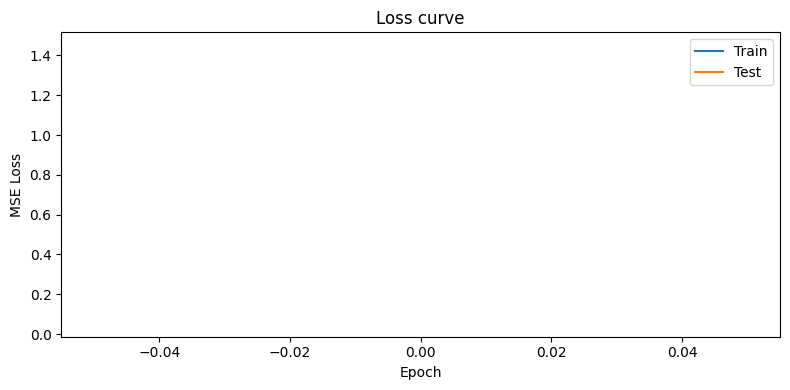

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(test_losses,  label='Test')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss curve')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Save and load

`train()` already saves the best checkpoint to `save_path`.
To reload later (e.g. after restarting the kernel):

In [ ]:
unet_loaded = load_unet(save_path, channels=channels, convs_per_level=cpl)
# unet_loaded is already in eval mode and on `device`

## 6. Generate images

`generate_image` runs the full reverse diffusion chain (T steps).
Returns a tensor of shape (n_images, 1, 28, 28).
`stochasticity=1.0` is full DDPM sampling; 0.0 is deterministic.

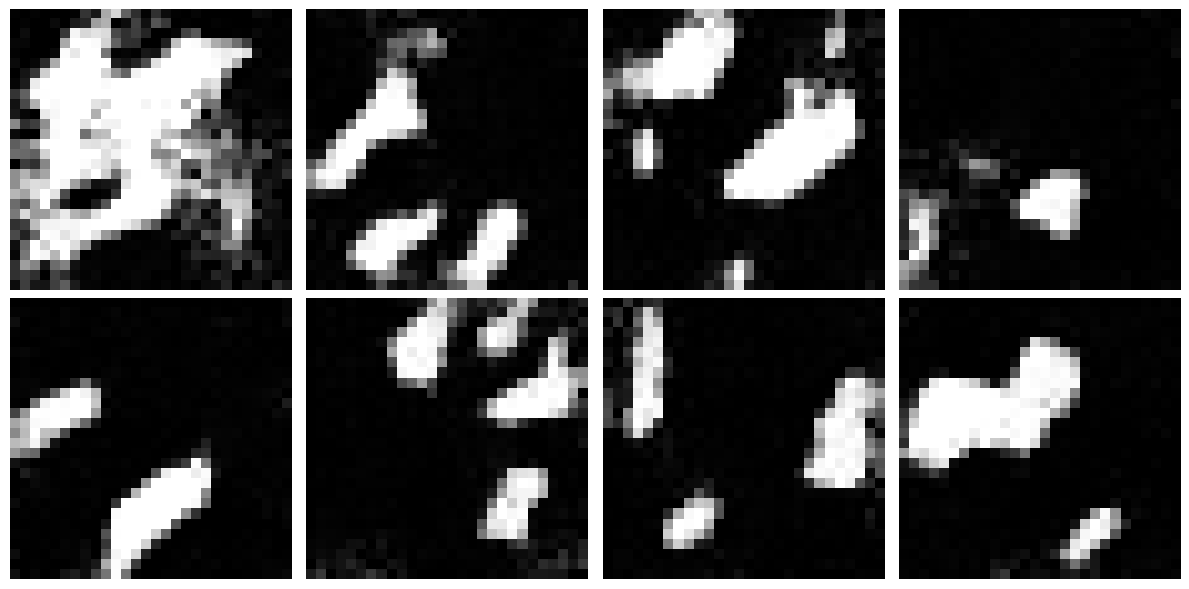

In [ ]:
x = generate_image(unet_loaded, scheduler, stochasticity=1.0, n_images=8)
plot_generated(x, ncol=4)

### Intermediates

You can inspect the denoising trajectory by returning intermediate steps.

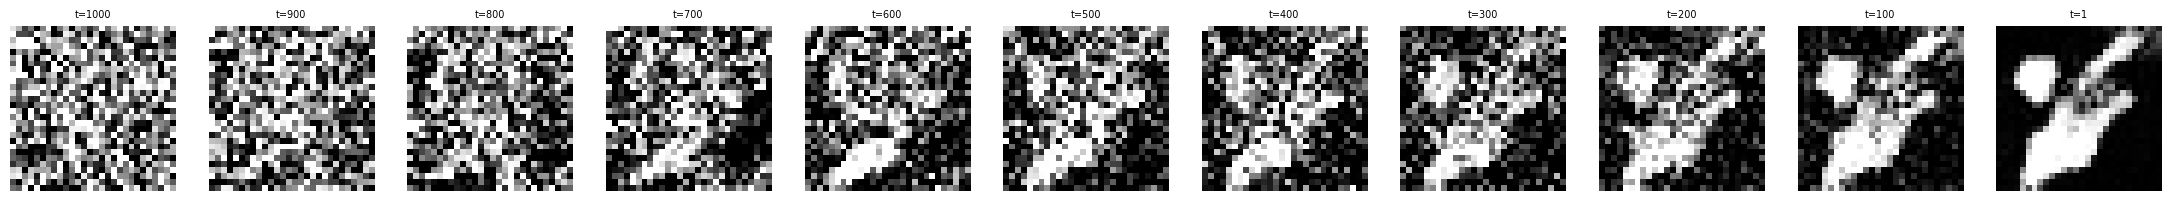

In [ ]:
x_final, intermediates = generate_image(
    unet_loaded, scheduler, stochasticity=1.0, n_images=1, return_intermediates=True
)

# Plot every 100th step
fig, axes = plt.subplots(1, 11, figsize=(22, 2))
steps_to_show = list(range(0, 1000, 100)) + [999]
for ax, idx in zip(axes, steps_to_show):
    img = intermediates[idx].squeeze()
    if img.min() < 0:
        img = (img + 1) / 2
    ax.imshow(img.clamp(0, 1), cmap='gray')
    ax.set_title(f't={1000 - idx}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()